In [5]:
# Prerequisites
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import scienceplots  # noqa: F401
from numba import njit, prange
import pandas as pd
import warnings
import linecache
import os

plt.style.use(["science", "high-vis", "grid"])
plt.rcParams.update(
    {
        "figure.figsize": (9, 9),
        "lines.markersize": 5,
        "lines.linewidth": 1.5,
        "axes.labelsize": 14,
        "axes.titlesize": 15,
        "figure.titlesize": 18,
        "legend.fontsize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "figure.constrained_layout.use": True,
        "legend.frameon": True,
        "axes.titlepad": 10,
    }
)


def warning_custom(message, category, filename, lineno, file=None, line=None):
    src = linecache.getline(filename, lineno).strip()
    short_file = os.path.basename(filename)
    print(f"{category.__name__} in {short_file}, line {lineno}: {message}\n    {src}")


warnings.showwarning = warning_custom

%config InlineBackend.figure_formats = ['svg']

### $a)$

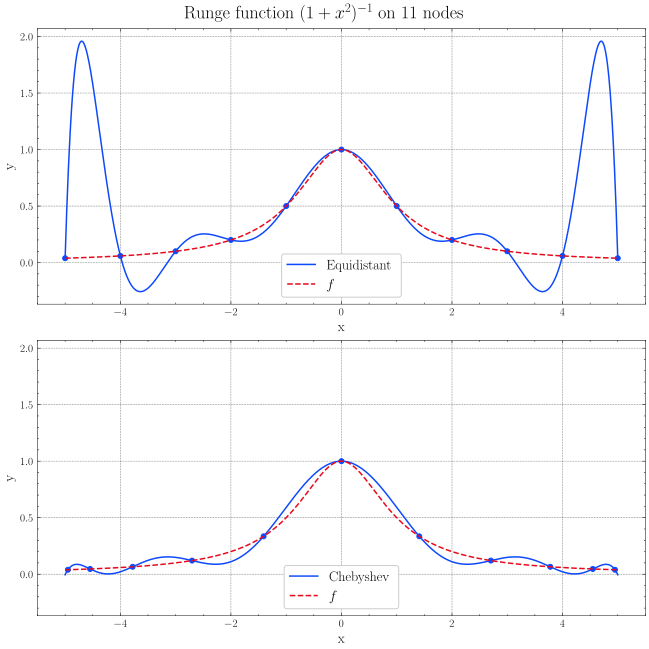

In [6]:
@njit(parallel=True)
def lagrange(x_data, y_data, x_eval):
    """Lagrange interpolation

    Args:
        x_data (array): x0,...,xn
        y_data (array): y0,...,yn
        x_eval (array): Evaluation points

    Returns:
        array: the value of the interpolation polynomial in x_eval
    """
    n = len(x_data) - 1
    eta = len(x_eval)
    y_eval = np.empty(eta)

    for k in prange(eta):
        p = 0.0  # p_n(x_eval[k])
        for i in range(n + 1):
            L_i = 1.0
            for j in range(n + 1):
                if i != j:
                    L_i *= (
                        (x_eval[k] - x_data[j]) / (x_data[i] - x_data[j])
                    )  # L_i(x_eval[k]) = prod_{j=0, j!=i} (x_eval[k]-x_data[j])/(x_data[i]-x_data[j])
            p += y_data[i] * L_i
        y_eval[k] = p

    return y_eval


@njit
def cheby_nodes(a, b, n):
    """Chebyshev nodes on [a,b]

    Args:
        a (float): left bound interval
        b (float): right bound interval
        n (int): number of nodes - 1

    Returns:
        array: nodes on the interval
    """
    # n + 1 cheby nodes in the interval [a, b]
    i = np.arange(n + 1)  # i = [0, 1, 2, 3,..., n]
    x = np.cos((2 * i + 1) * np.pi / (2 * (n + 1)))  # nodes over the interval [-1,1]
    return 0.5 * (b - a) * x + 0.5 * (b + a)  # nodes over the interval [a, b]


@njit
def runge_f(x):
    return 1 / (x**2 + 1)


def plotA(n=10, a=-5, b=5):
    x_equi = np.linspace(a, b, n + 1)
    x_cheby = cheby_nodes(a=a, b=b, n=n)

    y_equi = runge_f(x=x_equi)
    y_cheby = runge_f(x=x_cheby)
    x_eval = np.linspace(a, b, 1000)
    y_true = runge_f(x=x_eval)

    fig, (ax1, ax2) = plt.subplots(2, 1, sharey=True)

    ax1.plot(
        x_eval,
        lagrange(x_data=x_equi, y_data=y_equi, x_eval=x_eval),
        label="Equidistant",
    )
    ax1.scatter(x_equi, y_equi)

    ax2.plot(
        x_eval,
        lagrange(x_data=x_cheby, y_data=y_cheby, x_eval=x_eval),
        label="Chebyshev",
    )
    ax2.scatter(x_cheby, y_cheby)

    for ax in (ax1, ax2):
        ax.plot(x_eval, y_true, "--", label=r"$f$")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend(loc="lower center")

    plt.suptitle(f"Runge function $(1+x^2)^{{-1}}$ on {n + 1} nodes")
    plt.show()


plotA()

### $b)$

We have $f(x) = \cos(2\pi x)$. Want to show  
$$
\lim_{n \to \infty} \| f(x) - p_n(x) \|_\infty = 0
$$  

and similarly for max norm on both equidistant nodes and Chebyshev nodes on $[0,1]$.  



Thm 6.10 in Süli & Mayers gives  

$$
\| f(x) - p_n(x) \|_\infty \le \frac{M_{n+1}}{(n+1)!} \max_{x \in [a,b]} | \pi_{n+1}(x) |
$$  

if $f$ is continuous and real valued on the closed interval $[a,b]$. $f(x) = \cos(2\pi x) \in C^\infty[0,1]$, so the theorem holds. Then  

$$
\lim_{n \to \infty} \max_{x \in [0,1]} | f(x) - p_n(x) | 
\le \lim_{n \to \infty} \frac{M_{n+1}}{(n+1)!} \max_{x \in [0,1]} | \pi_{n+1}(x) |
$$  

So we have convergence if right side is equal $0$.  With $M_{n+1} = \max_{\zeta \in [a,b]} \left| f ^{n+1}(\zeta) \right|  $ it is
$$ 
\max_{\zeta \in [0,1]} \left| \frac{d^{n+1}}{d \zeta^{n+1}} \cos(2\pi \zeta) \right| \le (2\pi)^{n+1}
$$.  

since $\cos(x)$ is bounded by $[-1,1]$. Then  

$$
\frac{M_{n+1}}{(n+1)!} \max_{x \in [0,1]} | \pi_{n+1}(x) | 
\le \frac{(2\pi)^{n+1}}{(n+1)!} \max_{x \in [0,1]} | \pi_{n+1}(x)  |
$$  


With equidistant nodes use that  
$$
\left| \pi_{n+1}(x) \right| \le \left( \frac{b -a}{n} \right)^{n+1}  \cdot \frac{n!}{4}.
$$

Then  

$$
\begin{align*}
    \frac{M_{n+1}}{(n+1)!} \max_{x \in [0,1]} \left| \pi_{n+1}(x) \right| 
&\le \frac{(2\pi)^{n+1}}{(n+1)!} \cdot  \left( \frac{1-0}{n} \right)^{n+1}  \cdot \frac{n!}{4}\\
&= \frac{(2\pi)^{n+1}}{4n^{n+1}(n+1)}
\end{align*}
$$
is an upper bound for the error on equidistant nodes in the infinity norm.

For Chebyshev nodes (8.7) we have that

$$
\begin{align*}
    \| f(x) - p_n(x) \|_\infty &\le \frac{\left( b-a \right) ^{n+1}}{2^{2n+1} \left( n+1 \right)!} M_{n+1} \\
    &\le \frac{1^{n+1}}{2^{2n+1} \left( n+1 \right)!} (2\pi)^{n+1} \\
    &= \frac{(2\pi)^{n+1}}{2^{2n+1} \left( n+1 \right)!} \\
    &=2\frac{\left( \pi / 2 \right) ^{n+1}}{(n+1)!}.
\end{align*}
$$

For the $2$-norm consider Lemma 8.1 which states that  

$$
\| g \|_2 \le W \| g \|_\infty \quad \text{for any function } g \in C[a,b].
$$  

Now set $g \equiv f(x) - p_n(x)$, then we get as $n \to \infty$ that $\| g \|_2 \to 0$ because $\| g \|_\infty \to 0$. The factorial will dominate in the Chebyshev case, and $n^{n+1}$ will dominate in the equidistant case. I.e., the bounds for $\| g \|_\infty$ go to $0$ as $n \to \infty$ in both cases and in both norms.
$g$ is a linear combination of continuous functions, so the lemma holds.

For $f(x) = e^{3x}\left( \sin (2x) \right) $, remember that $\sin x = \Im (e^{ix})$. Then

$$
\begin{align*}
    f(x)&=e^{3x} \cdot  \Im (e^{2ix}) \\
    &= \Im (e^{(3+2i)x}).
\end{align*}
$$
So it is 
$$
\begin{align*}
    \left| f^{n+1}(x) \right| &= \left| (3+2i)^{n+1}\cdot  e^{3x}\left( \sin (2x) \right)\right|\\
    &\le \left| 3+2i \right|^{n+1} \cdot  \left| e^{3x} \right| \cdot \left| \sin (2x) \right| \\
    &\le \left( \sqrt{13} \right)^{n+1} \cdot \left| e^{3x} \right| 
\end{align*}
$$
and then 
$$
\begin{align*}
    M_{n+1} &\le \left( \sqrt{13} \right)^{n+1} \max_{x \in [0, \pi /4]} \left| e^{3x} \right|\\
    &= \left( \sqrt{13} \right)^{n+1} \cdot e^{3\pi /4}.
\end{align*}
$$

So a bound for $f(x) =e^{3x}\left( \sin (2x) \right) $ is then

$$
\begin{align*}
    \| f(x) - p_n(x) \|_\infty &\le \frac{M_{n+1}}{(n+1)!} \max_{x \in [a,b]} \left| \pi_{n+1}(x) \right| \\
    & \le e^{3\pi /4} \frac{\left( \sqrt{13} \right)^{n+1}}{(n+1)!}  \cdot \left( \frac{\pi /4-0}{n} \right)^{n+1}  \cdot \frac{n!}{4}\\
    &= e^{3\pi /4} \frac{\left( \sqrt{13} \pi \right)^{n+1}}{4^{n+2}\ n^{n+1}(n+1)}
\end{align*}
$$
for equidistant nodes. For Chebyshev nodes it is

$$
\begin{align*}
    \| f(x) - p_n(x) \|_\infty &\le \frac{M_{n+1}}{(n+1)!} \max_{x \in [a,b]} \left| \pi_{n+1}(x) \right| \\
    & \le e^{3\pi /4} \frac{\left( \sqrt{13} \right)^{n+1}}{(n+1)!}  \cdot \frac{\left( \pi /4-0 \right) ^{n+1}}{2^{2n+1}}\\
    &= e^{3\pi /4} \frac{\left( \sqrt{13} \pi /4 \right)^{n+1}}{2^{2n+1}(n+1)!}\\
    &= e^{3\pi /4} \frac{\left( \sqrt{13} \pi\right)^{n+1}}{2^{4n+3}(n+1)!}
\end{align*}
$$

The same argument as above holds for the limit and consequently the $2$-norm.
Consider also that both functions are entire analytic functions, so the Runge-phenomenon will not be a problem (pp. 187, Süli & Mayers).

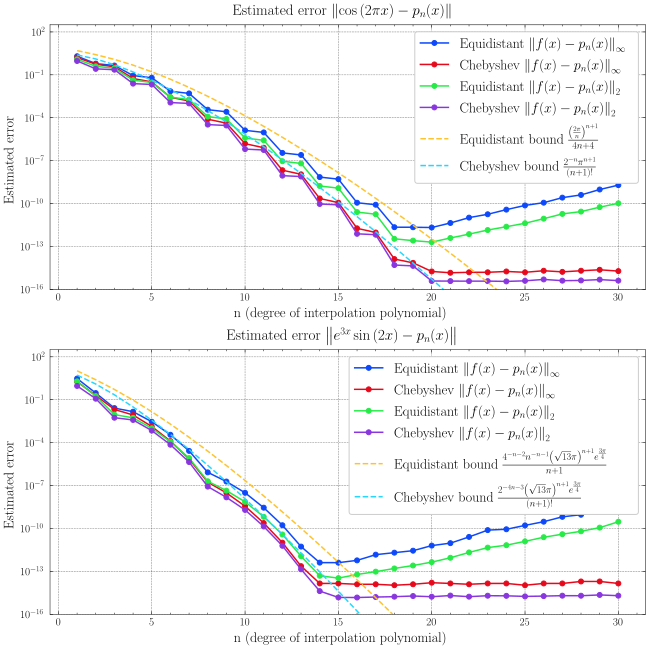

In [7]:
from scipy.special import factorial

x, k, n_ = sp.symbols(names="x k n")
f1 = sp.cos(2 * sp.pi * x)
f2 = sp.exp(3 * x) * sp.sin(2 * x)

error_bound_equi_1 = (2 * sp.pi / k) ** (k + 1) / (4 * (k + 1))
error_bound_cheby_1 = (sp.pi) ** (k + 1) / (
    2 ** (k) * sp.factorial(k + 1)
)  # Theorem 8.1
error_bound_equi_2 = (
    sp.exp(3 * sp.pi / 4)
    * (sp.sqrt(13) * sp.pi) ** (k + 1)
    / (4 ** (k + 2) * k ** (k + 1) * (k + 1))
)
error_bound_cheby_2 = (
    sp.exp(3 * sp.pi / 4)
    * (sp.sqrt(13) * sp.pi) ** (k + 1)
    / (2 ** (4 * k + 3) * sp.factorial(k + 1))
)

bound_func_equi_1 = sp.lambdify(
    args=k, expr=error_bound_equi_1, modules=[{"factorial": factorial}, "numpy"]
)
bound_func_cheby_1 = sp.lambdify(
    args=k, expr=error_bound_cheby_1, modules=[{"factorial": factorial}, "numpy"]
)
bound_func_equi_2 = sp.lambdify(
    args=k, expr=error_bound_equi_2, modules=[{"factorial": factorial}, "numpy"]
)
bound_func_cheby_2 = sp.lambdify(
    args=k, expr=error_bound_cheby_2, modules=[{"factorial": factorial}, "numpy"]
)
f_funcs = (
    sp.lambdify(args=x, expr=f1, modules="numpy"),
    sp.lambdify(args=x, expr=f2, modules="numpy"),
)

fs = (f1, f2)

n_max = 30
n_range = np.arange(1, n_max + 1, dtype=int)
domains = [(0, 1), (0, np.pi / 4)]
fig, axs = plt.subplots(
    2,
    1,
)

for i, (f, (a, b)) in enumerate(zip(f_funcs, domains)):
    norm_inf_equi = np.zeros(n_max)
    norm_inf_cheby = np.zeros(n_max)
    norm_2_equi = np.zeros(n_max)
    norm_2_cheby = np.zeros(n_max)

    for n in n_range:
        N = 100 * int(n)
        x_eval = np.linspace(a, b, N + 1)
        x_equi = np.linspace(a, b, int(n) + 1)
        x_cheby = cheby_nodes(a=a, b=b, n=int(n))

        y_equi = lagrange(x_data=x_equi, y_data=f(x_equi), x_eval=x_eval)
        y_cheby = lagrange(x_data=x_cheby, y_data=f(x_cheby), x_eval=x_eval)

        idx = int(n) - 1
        norm_inf_equi[idx] = np.max(np.abs(f(x_eval) - y_equi))
        norm_inf_cheby[idx] = np.max(np.abs(f(x_eval) - y_cheby))
        norm_2_equi[idx] = np.sqrt((b - a) / N * np.sum((f(x_eval) - y_equi) ** 2))
        norm_2_cheby[idx] = np.sqrt((b - a) / N * np.sum((f(x_eval) - y_cheby) ** 2))

    axs[i].semilogy(
        n_range,
        norm_inf_equi,
        "o-",
        label=r"Equidistant $\left\|  f(x) - p_n(x) \right\|_{{\infty}}$",
    )
    axs[i].semilogy(
        n_range,
        norm_inf_cheby,
        "o-",
        label=r"Chebyshev $\left\|  f(x) - p_n(x) \right\|_{{\infty}}$",
    )
    axs[i].semilogy(
        n_range,
        norm_2_equi,
        "o-",
        label=r"Equidistant $\left\|  f(x) - p_n(x) \right\|_2$",
    )
    axs[i].semilogy(
        n_range,
        norm_2_cheby,
        "o-",
        label=r"Chebyshev $\left\|  f(x) - p_n(x) \right\|_2$",
    )

    axs[i].set_xlabel("n (degree of interpolation polynomial)")
    axs[i].set_ylabel("Estimated error")
    axs[i].set_title(rf"Estimated error $\left\| {sp.latex(fs[i])} - p_n(x) \right\|$")

axs[0].semilogy(
    n_range,
    bound_func_equi_1(n_range.astype(float)),
    "--",
    label=rf"Equidistant bound ${sp.latex(error_bound_equi_1.subs(k, n_))}$",
)
axs[0].semilogy(
    n_range,
    bound_func_cheby_1(n_range.astype(float)),
    "--",
    label=rf"Chebyshev bound ${sp.latex(error_bound_cheby_1.subs(k, n_))}$",
)
axs[1].semilogy(
    n_range,
    bound_func_equi_2(n_range.astype(float)),
    "--",
    label=rf"Equidistant bound ${sp.latex(error_bound_equi_2.subs(k, n_))}$",
)
axs[1].semilogy(
    n_range,
    bound_func_cheby_2(n_range.astype(float)),
    "--",
    label=rf"Chebyshev bound ${sp.latex(error_bound_cheby_2.subs(k, n_))}$",
)

for i in [0, 1]:
    axs[i].legend()
    axs[i].set_ylim(10 ** (-16), 10**2.5)

plt.show()

### $c)$

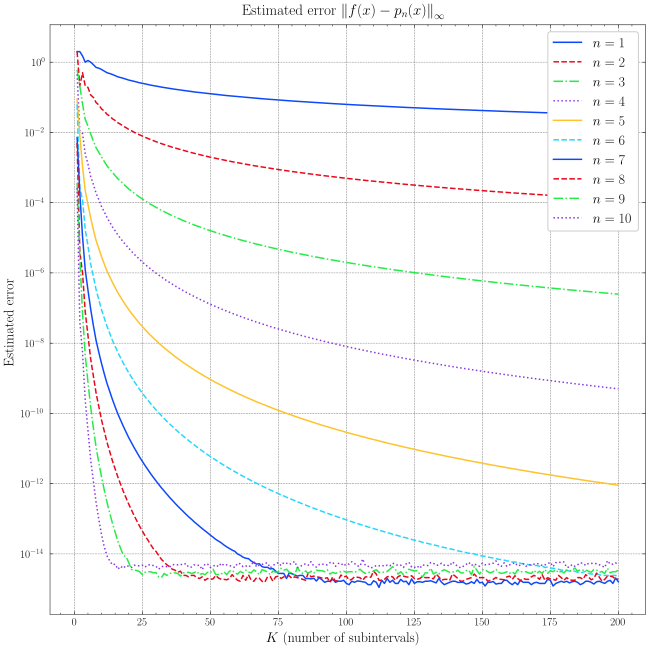

In [8]:
@njit
def f_cos(x):
    return np.cos(2 * np.pi * x)


@njit
def taskC(a, b, K_max, n_max=10):
    K_vals = np.arange(1, K_max + 1)
    results = np.zeros((n_max, K_max))
    for i in range(K_max):
        K = K_vals[i]
        v_a_arr = np.empty(K)
        v_b_arr = np.empty(K)
        for j in range(K):
            v_a_arr[j] = a + j * (b - a) / K
            v_b_arr[j] = a + (j + 1) * (b - a) / K
        for n in range(1, n_max + 1):
            norm_inf_subints = np.zeros(K)
            for j in range(K):
                v_a = v_a_arr[j]
                v_b = v_b_arr[j]
                x_equi = np.linspace(v_a, v_b, n)
                x_eval = np.linspace(v_a, v_b, 100 * n)
                y_equi = f_cos(x_equi)
                y_eval = lagrange(x_equi, y_equi, x_eval)
                norm_inf_subints[j] = np.max(np.abs(f_cos(x_eval) - y_eval))
            results[n - 1, i] = np.max(norm_inf_subints)
    return K_vals, results


K_vals, results = taskC(a=0, b=1, K_max=200, n_max=10)

fig, ax = plt.subplots()
for n in range(10):
    ax.semilogy(K_vals, results[n], label=rf"$n = {n + 1}$")
ax.set_title(r"Estimated error $\left\| f(x) - p_n(x) \right\|_{\infty}$")
ax.set_xlabel(r"$K$ (number of subintervals)")
ax.set_ylabel("Estimated error")
ax.legend()
plt.show()

### $d)$

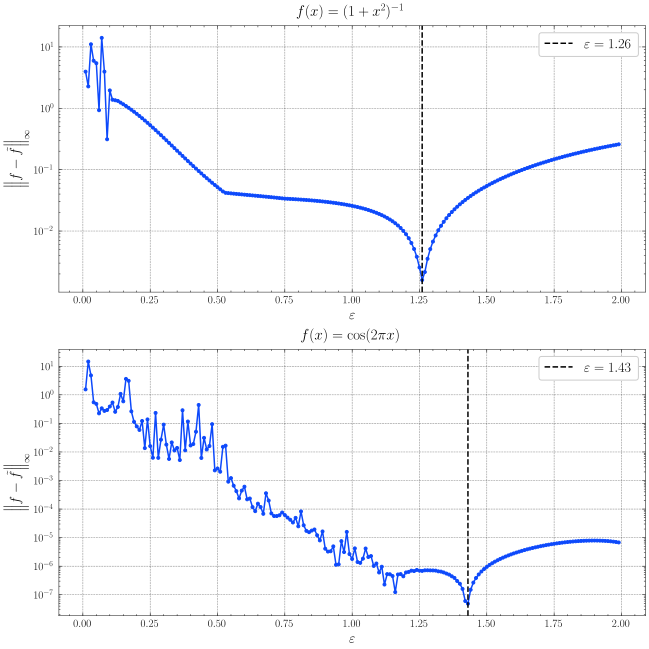

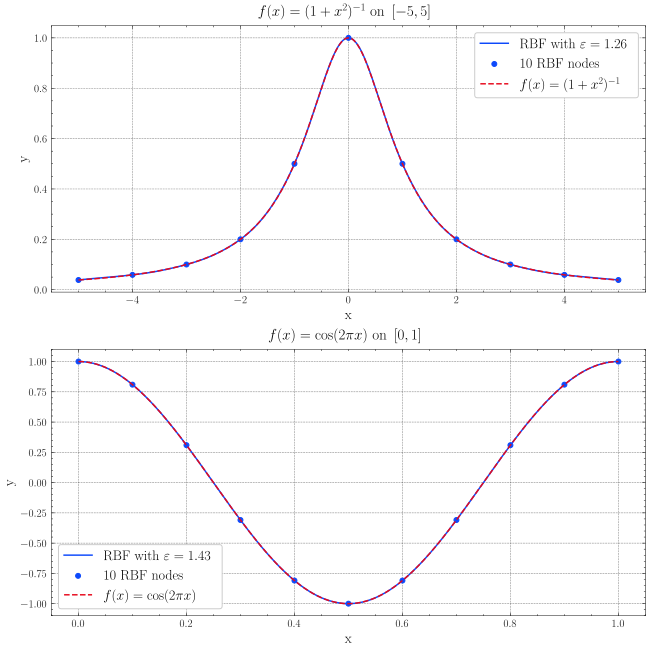

In [9]:
@njit
def phi(r, epsilon):
    return np.exp(-((epsilon * r) ** 2))


@njit
def RBF(x_data, y_data, x_eval, epsilon=1.26):
    xi_minus_xj = x_data[:, np.newaxis] - x_data
    M = phi(r=np.abs(xi_minus_xj), epsilon=epsilon)
    w = np.linalg.solve(M, y_data)

    x_minus_xi = x_eval[:, np.newaxis] - x_data
    phi_eval = phi(r=np.abs(x_minus_xi), epsilon=epsilon)
    y_eval = phi_eval @ w

    return y_eval


def find_min_epsilon(search_a, search_b, tol, funcs):
    epsilon_min = np.zeros(2)
    a = [-5, 0]
    b = [5, 1]
    fig, axs = plt.subplots(2, 1)
    for i in range(2):
        epsilons = np.arange(search_a, search_b, tol)
        norms = np.ones_like(epsilons)
        x_data = np.linspace(a[i], b[i], n + 1)
        x_eval = np.linspace(a[i], b[i], n_eval)
        y_data = funcs[i](x_data)
        y_true = funcs[i](x_eval)

        for j in prange(epsilons.shape[0]):
            y_eval = RBF(
                x_data=x_data, y_data=y_data, x_eval=x_eval, epsilon=epsilons[j]
            )
            norms[j] = np.max(np.abs(y_true - y_eval))

        epsilon_min[i] = epsilons[np.argmin(norms)]

        axs[i].semilogy(epsilons, norms, "o-", markersize=3)
        axs[i].axvline(
            x=epsilon_min[i],
            linestyle="--",
            color="black",
            label=rf"$\varepsilon = {epsilon_min[i]:.2f}$",
        )
        axs[i].set_xlabel(r"$\varepsilon$")
        axs[i].set_ylabel(r"$\left\| f - \tilde{{f}} \right\|_\infty$")
        axs[i].legend()
        axs[i].set_title(rf"$f(x) ={funcs_latex[i]}$")
    # plt.suptitle(
    #     r"$\left\| f - \tilde{{f}} \right\|_\infty \;\text{{vs.}}\; \varepsilon$"
    # )
    plt.show()

    return epsilon_min


funcs = [runge_f, f_cos]
funcs_latex = ["(1 + x^2)^{{-1}}", "\\cos(2\\pi x)"]
n = 10
n_eval = 100 * n
a = [-5, 0]
b = [5, 1]


epsilons = find_min_epsilon(search_a=0.01, search_b=2.0, tol=0.01, funcs=funcs)


fig, axs = plt.subplots(2, 1)
for i, func in enumerate(funcs):
    x_data = np.linspace(a[i], b[i], n + 1)
    x_eval = np.linspace(a[i], b[i], n_eval)
    y_data = func(x=x_data)
    y_eval = RBF(x_data=x_data, y_data=y_data, x_eval=x_eval, epsilon=epsilons[i])

    axs[i].plot(
        x_eval,
        y_eval,
        label=rf"RBF with $\varepsilon = {epsilons[i]}$",
    )
    axs[i].scatter(x_data, y_data, label=rf"${n}$ RBF nodes")
    axs[i].plot(x_eval, func(x=x_eval), "--", label=rf"$f(x) = {funcs_latex[i]}$")
    axs[i].legend()
    axs[i].set_title(
        rf"$f(x)={funcs_latex[i]} \text{{ on }}\left[{a[i]}, {b[i]}\right]$"
    )
    axs[i].set_xlabel("x")
    axs[i].set_ylabel("y")
plt.show()

### $e)$

RuntimeWarning in tracer.py, line 54: divide by zero encountered in matmul
    return f_raw(*args, **kwargs)
RuntimeWarning in tracer.py, line 54: overflow encountered in matmul
    return f_raw(*args, **kwargs)
RuntimeWarning in tracer.py, line 54: invalid value encountered in matmul
    return f_raw(*args, **kwargs)
RuntimeWarning in 3488237091.py, line 16: divide by zero encountered in matmul
    y_eval = phi_eval @ w
RuntimeWarning in 3488237091.py, line 16: overflow encountered in matmul
    y_eval = phi_eval @ w
RuntimeWarning in 3488237091.py, line 16: invalid value encountered in matmul
    y_eval = phi_eval @ w


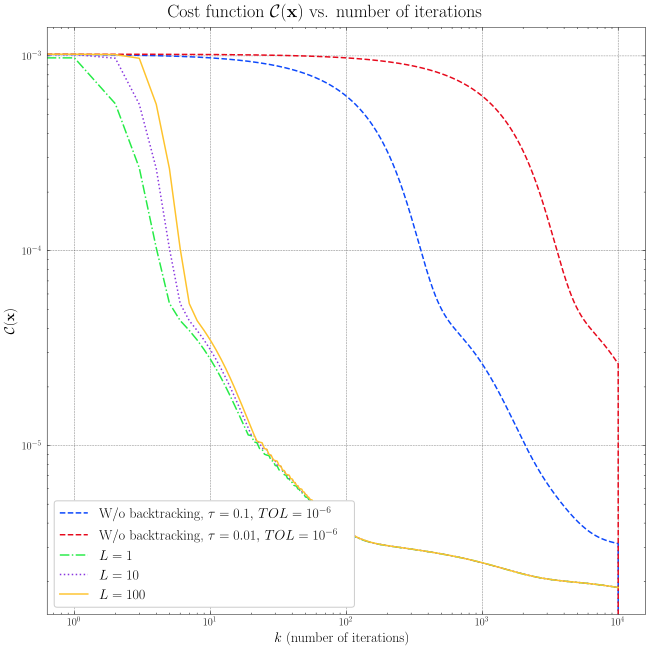

In [10]:
from autograd import grad
import autograd.numpy as np


def phi_ag(r, epsilon):
    return np.exp(-((epsilon * r) ** 2))


def RBF_ag(x_data, y_data, x_eval, epsilon):
    xi_minus_xj = x_data[:, np.newaxis] - x_data
    M = phi_ag(r=np.abs(xi_minus_xj), epsilon=epsilon)
    w = np.linalg.solve(M, y_data)

    x_minus_xi = x_eval[:, np.newaxis] - x_data
    phi_eval = phi_ag(r=np.abs(x_minus_xi), epsilon=epsilon)
    y_eval = phi_eval @ w

    return y_eval


def runge_f_ag(x):
    return 1 / (x**2 + 1)


epsilon = 1
a, b = -5, 5
n = 10
N = 1000
eta_vals = np.linspace(a, b, N + 1)
f_eta_vals = runge_f_ag(eta_vals)
x_data = np.linspace(a, b, n + 1)


def cost_func(param):
    epsilon = param[-1]
    x_data = param[:-1]
    RBF_vals = RBF_ag(x_data, runge_f_ag(x_data), eta_vals, epsilon)
    cost = (b - a) / N * np.sum((f_eta_vals - RBF_vals) ** 2)
    return cost


def gradient_descent(step, tol, max_iter, param):
    grad_func = grad(cost_func)
    gradient = grad_func(param)

    error = 1
    k = 0
    param_current = param
    cost_vals = np.zeros(max_iter)

    while error > tol:
        param_next = param_current - step * gradient

        error = np.max(np.abs(param_next - param_current))
        cost_vals[k] = cost_func(param=param_current)
        param_current = param_next
        gradient = grad_func(param_current)
        k += 1

        if k >= max_iter - 1:
            # print("Reached max iterations")
            return param[:-1], param[-1], cost_vals[: k + 1]

    return param[:-1], param[-1], cost_vals[: k + 1]


def gradient_descent_bt(param, L, rho_up, rho_down, max_iter):
    grad_func = grad(cost_func)
    phi = cost_func(param=param)
    cost_vals = np.zeros(max_iter)

    for k in range(max_iter):
        g = grad_func(param)
        cost_vals[k] = cost_func(param)

        for t in range(1000):
            param_tilde = param - 1 / L * g
            phi_tilde = cost_func(param=param_tilde)

            if (
                phi_tilde
                <= phi
                + np.dot(g, param_tilde - param)
                + L / 2 * np.max(np.abs(param_tilde - param)) ** 2
            ):
                param = param_tilde
                phi = phi_tilde
                L = rho_down * L
                break
            else:
                L = rho_up * L

        if k >= max_iter - 1:
            # print("Reached max iterations")
            return param[:-1], param[-1], cost_vals[: k + 1]

    return param[:-1], param[-1], cost_vals[: k + 1]


param_init = np.append(x_data, epsilon)
fig, ax = plt.subplots()

for i, step in enumerate([0.1, 0.01]):
    x_optimal, epsilon_optimal, cost_vals = gradient_descent(
        step=step, max_iter=10000, tol=1e-6, param=param_init
    )

    ax.loglog(
        np.arange(cost_vals.shape[0]),
        cost_vals,
        "--",
        label=rf"W/o backtracking, $\tau={step},\, TOL = 10^{{-6}}$",
    )

for i, L in enumerate([1, 10, 100]):
    x_optimal, epsilon_optimal, cost_vals = gradient_descent_bt(
        param=param_init,
        L=L,
        rho_up=10,
        rho_down=0.1,
        max_iter=10000,
    )

    ax.loglog(np.arange(cost_vals.shape[0]), cost_vals, label=rf"$L={L}$")
ax.set_xlabel(r"$k$ (number of iterations)")
ax.set_ylabel(r"$\mathcal{C}(\mathbf{x})$")
ax.legend(loc="lower left")
plt.suptitle(r"Cost function $\mathcal{C}(\mathbf{x})$ vs. number of iterations")
plt.show()

RuntimeWarning in 3488237091.py, line 16: divide by zero encountered in matmul
    y_eval = phi_eval @ w
RuntimeWarning in 3488237091.py, line 16: overflow encountered in matmul
    y_eval = phi_eval @ w
RuntimeWarning in 3488237091.py, line 16: invalid value encountered in matmul
    y_eval = phi_eval @ w
RuntimeWarning in tracer.py, line 54: divide by zero encountered in matmul
    return f_raw(*args, **kwargs)
RuntimeWarning in tracer.py, line 54: overflow encountered in matmul
    return f_raw(*args, **kwargs)
RuntimeWarning in tracer.py, line 54: invalid value encountered in matmul
    return f_raw(*args, **kwargs)


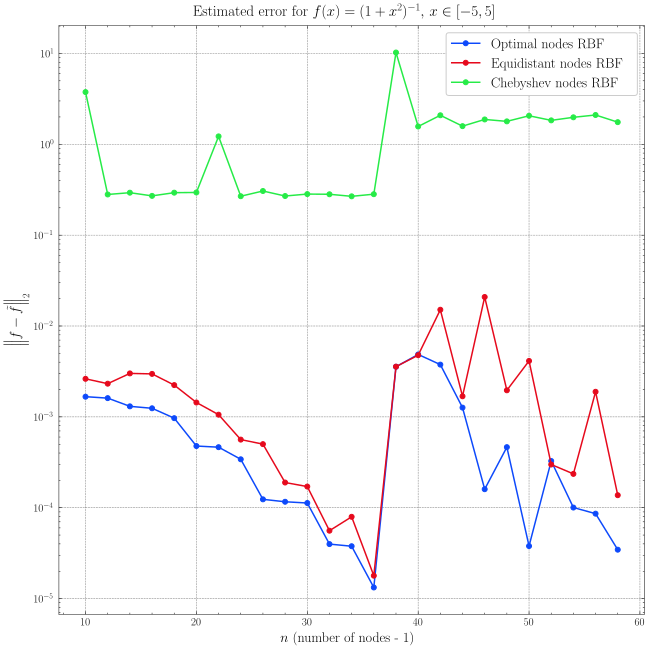

,Error Optimal,Error Equidistant,Error Chebyshev
n,,,
10,1.6675e-03,2.6232e-03,3.7576e+00
12,1.6079e-03,2.3191e-03,2.8045e-01
14,1.3061e-03,3.0094e-03,2.9337e-01
16,1.2433e-03,2.9721e-03,2.7063e-01
18,9.6761e-04,2.2380e-03,2.9347e-01
20,4.7751e-04,1.4395e-03,2.9507e-01
22,4.6383e-04,1.0570e-03,1.2225e+00
24,3.4125e-04,5.6201e-04,2.6834e-01
26,1.2372e-04,5.0120e-04,3.0613e-01


In [12]:
n_vals = [n for n in range(10, 60, 2)]
a, b = -5, 5
errors_optimal = np.zeros(len(n_vals))
errors_equi_RBF = np.zeros(len(n_vals))
errors_cheby_RBF = np.zeros(len(n_vals))


def norm_2(y_true, y_pred, a, b, N):
    return np.sqrt((b - a) / N * np.sum((y_true - y_pred) ** 2))


for i, n in enumerate(n_vals):
    epsilon_guess = 1
    N = 100 * n
    eta_vals = np.linspace(a, b, N + 1)
    f_eta_vals = runge_f_ag(eta_vals)
    x_equi = np.linspace(a, b, n + 1)
    param_init = np.append(x_equi, epsilon_guess)
    x_optimal, epsilon_optimal, cost_vals = gradient_descent_bt(
        param=param_init,
        L=L,
        rho_up=10,
        rho_down=0.1,
        max_iter=500,
    )

    RBF_optimal = RBF(
        x_data=x_optimal,
        y_data=runge_f(x_optimal),
        x_eval=eta_vals,
        epsilon=epsilon_optimal,
    )
    RBF_equi = RBF(
        x_data=x_equi, y_data=runge_f(x_equi), x_eval=eta_vals, epsilon=epsilon_optimal
    )
    RBF_cheby = RBF(
        x_data=x_cheby,
        y_data=runge_f(x_cheby),
        x_eval=eta_vals,
        epsilon=epsilon_optimal,
    )

    errors_optimal[i] = norm_2(f_eta_vals, RBF_optimal, a, b, N)
    errors_equi_RBF[i] = norm_2(f_eta_vals, RBF_equi, a, b, N)
    errors_cheby_RBF[i] = norm_2(f_eta_vals, RBF_cheby, a, b, N)

fig, ax = plt.subplots()
ax.semilogy(
    n_vals,
    errors_optimal,
    "o-",
    label=r"Optimal nodes RBF",
)
ax.semilogy(
    n_vals,
    errors_equi_RBF,
    "o-",
    label=r"Equidistant nodes RBF",
)
ax.semilogy(
    n_vals,
    errors_cheby_RBF,
    "o-",
    label=r"Chebyshev nodes RBF",
)

ax.set_title(rf"Estimated error for $f(x)={funcs_latex[0]}, \, x \in [-5,5]$")
ax.set_xlabel(r"$n$ (number of nodes - 1)")
ax.set_ylabel(r"$\left\| f - \tilde{f}\right\|_2$")
ax.legend()
plt.show()

data = {
    "n": n_vals,
    "Error Optimal": errors_optimal,
    "Error Equidistant": errors_equi_RBF,
    "Error Chebyshev": errors_cheby_RBF,
}

df_errors = pd.DataFrame(data)
df_errors = df_errors.set_index("n")

pd.options.display.float_format = "{:.4e}".format
display(df_errors)